Name:Rushi Rvairaj Gujarathi ||Roll no-17 ||PRN NO-1252090017

Assingment no:9

Problem statement:
Write a program to do following:
This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.

Apply Data pre-processing
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.
Data Set: https://www.kaggle.com/shwetabh123/mall-customers

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


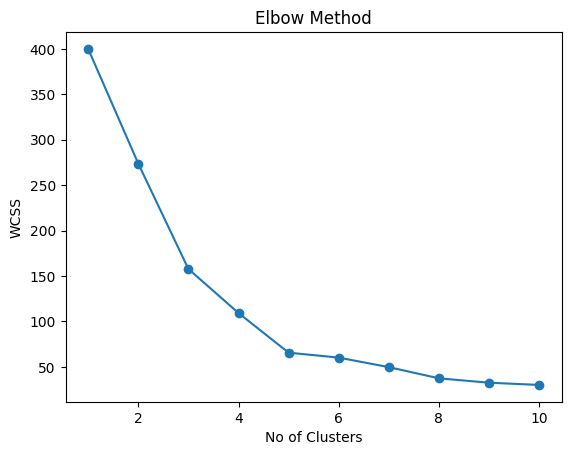

In [ ]:
from numpy.random.mtrand import RandomState
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score


# Load Dataset
data = pd.read_csv("/content/Mall_Customers.csv")

# Data Cleaning
data = data.dropna()
print(data.isnull().sum())

data = data.drop_duplicates()
print(data.head())

# Select Features
x = data.iloc[:, [3,4]].values

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# Train Test Split
X_train, X_test = train_test_split(x_scaled, test_size=0.2, random_state=42)

# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.show()

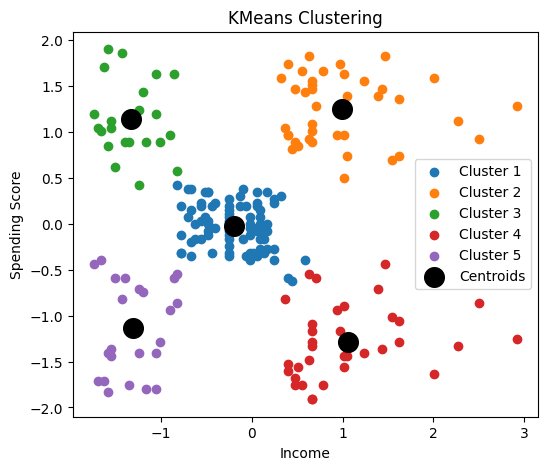


Silhouette Score KMeans: 0.5546571631111091


In [ ]:
#KMeans Clustering
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Scatter Plot KMeans
print("\n")
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[y_kmeans==0,0], X_scaled[y_kmeans==0,1], label="Cluster 1")
plt.scatter(X_scaled[y_kmeans==1,0], X_scaled[y_kmeans==1,1], label="Cluster 2")
plt.scatter(X_scaled[y_kmeans==2,0], X_scaled[y_kmeans==2,1], label="Cluster 3")
plt.scatter(X_scaled[y_kmeans==3,0], X_scaled[y_kmeans==3,1], label="Cluster 4")
plt.scatter(X_scaled[y_kmeans==4,0], X_scaled[y_kmeans==4,1], label="Cluster 5")

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=200, c='black', label="Centroids")
plt.title("KMeans Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

# 8. Silhouette Score (KMeans)
score=silhouette_score(X_scaled,y_kmeans)
print("\nSilhouette Score KMeans:", score )

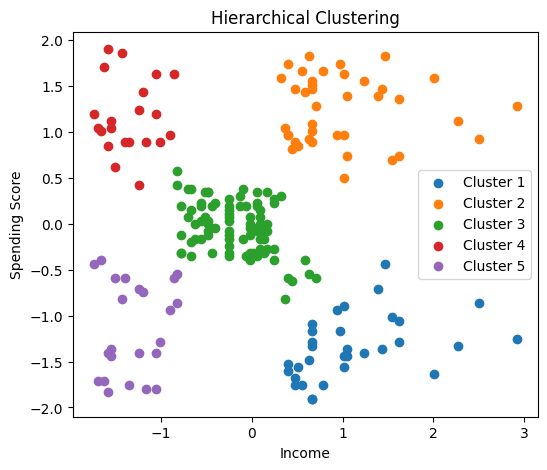


Silhouette Score Hierarchical: 0.5538089226688662 



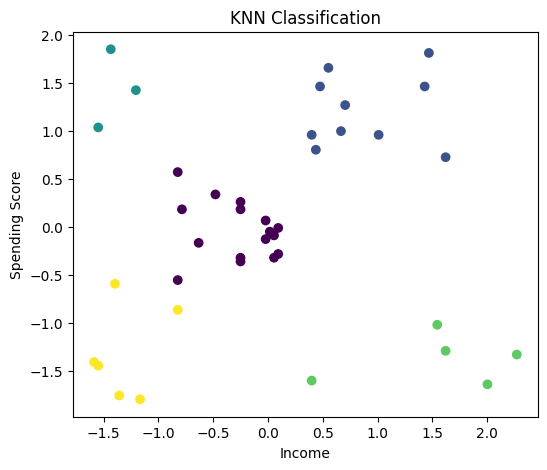


KNN Accuracy: 0.95








\n


In [ ]:
# 9. Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_scaled[y_hc==0,0], X_scaled[y_hc==0,1], label="Cluster 1")
plt.scatter(X_scaled[y_hc==1,0], X_scaled[y_hc==1,1], label="Cluster 2")
plt.scatter(X_scaled[y_hc==2,0], X_scaled[y_hc==2,1], label="Cluster 3")
plt.scatter(X_scaled[y_hc==3,0], X_scaled[y_hc==3,1], label="Cluster 4")
plt.scatter(X_scaled[y_hc==4,0], X_scaled[y_hc==4,1], label="Cluster 5")

plt.title("Hierarchical Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

# Silhouette Score (Hierarchical)
score_hc = silhouette_score(X_scaled, y_hc)
print("\nSilhouette Score Hierarchical:", score_hc,"\n")


#11. KNN Classification
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_kmeans, test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)

# 12. KNN Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(X_test[:,0], X_test[:,1], c=knn.predict(X_test))
plt.title("KNN Classification")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()
print("\nKNN Accuracy:", accuracy)

print("\n\n\n\n\n\n\n\n\n")